# Phase 3: Comprehensive Baseline Modeling — GARCH(1,1)

**Goal**: Scientifically establish the industry-standard benchmark for ALL 40 tickers across ALL 5 horizons ([12, 96, 192, 336, 720]).

This notebook performs a full sweep of 200 GARCH(1,1) models, providing the perfect baseline for TimeMixer.

### Experimental Setup:
- **Train set**: 2010 - 2023-12-31
- **Test set**: 2024-01-01 - 2026-03-30
- **Models**: 40 Tickers × 5 Horizons = 200 total GARCH models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from src.utils.config import cfg
from src.data.loader import DataLoader
from src.data.preprocessing import VolatilityProcessor
from src.models.baselines import BaselineForecaster
from src.models.evaluation import Evaluator

plt.style.use(cfg.viz.style)
sns.set_palette("tab10")

## 1. The Full Experimental Sweep
Run GARCH(1,1) for every ticker and every horizon.

In [2]:
loader = DataLoader()
proc = VolatilityProcessor()
bf = BaselineForecaster()
ev = Evaluator()

asset_classes = ['stock', 'etf', 'forex', 'crypto']
horizons = [12, 96, 192, 336, 720]

all_metrics = []
all_results = {}

# Use tqdm for progress tracking
for group in asset_classes:
    df = loader.load(group)
    tickers = df['Ticker'].unique()
    
    for ticker in tqdm(tickers, desc=f"Processing {group}"):
        try:
            df_ticker = df[df['Ticker'] == ticker].copy()
            
            # Ground Truth Actuals
            vol_df = proc.compute_volatility(df_ticker)
            if vol_df.empty:
                print(f"  [Error] Skipping {ticker}: Ohlc volatility calculation returned no rows.")
                continue

            _, test_actual_df = proc.train_test_split(vol_df)
            if test_actual_df.empty:
                print(f"  [Error] Skipping {ticker}: Test set (2024+) is empty.")
                continue

            actual_test_vol = test_actual_df['y'].values
            test_dates = test_actual_df['ds']
            
            if ticker not in all_results:
                all_results[ticker] = {}
            
            for h in horizons:
                # Forecast
                pred_vol = bf.fit_predict_garch(df_ticker, horizon=h, ticker=ticker)
                
                # Align
                min_len = min(len(actual_test_vol), len(pred_vol))
                y_true = actual_test_vol[:min_len]
                y_pred = pred_vol[:min_len]
                dates = test_dates[:min_len]
                
                all_results[ticker][h] = {'dates': dates, 'actual': y_true, 'pred': y_pred}
                
                # Compute metrics
                metrics = ev.compute_metrics(y_true, y_pred, model_name=f"GARCH_{ticker}_h{h}")
                if metrics:
                    metrics['AssetClass'] = group
                    metrics['Ticker'] = ticker
                    metrics['Horizon'] = h
                    all_metrics.append(metrics)
        except Exception as e:
            print(f"  [Critical] Unexpected error processing {ticker}: {e}")

if all_metrics:
    metrics_df = pd.DataFrame(all_metrics)
    metrics_df.to_csv('../results/metrics/baseline_results_exhaustive.csv', index=False)
    print(f"✓ All possible baseline models trained. Rows: {len(metrics_df)}")
    display(metrics_df.head())
else:
    print("❌ No baseline results were collected.")

2026-03-31 07:09:07 | INFO     | src.data.loader | Loading stock data from: /home/thota23/Volatility-Forecasting-in-Global-Financial-Markets-Using-TimeMixer/Data/stock.csv


2026-03-31 07:09:07 | INFO     | src.data.loader |   ✓ stock: 58,259 rows | 10 tickers | 2010-01-04 → 2026-03-30


Processing stock:   0%|          | 0/11 [00:00<?, ?it/s]

2026-03-31 07:09:07 | INFO     | src.data.preprocessing | Computing volatility | window=21d | primary=Yang-Zhang


2026-03-31 07:09:07 | INFO     | src.data.preprocessing |   ✓ 5,908 rows | 1 tickers | cols: ['ds', 'yz_vol', 'rolling_vol', 'unique_id', 'y']


...

2026-03-31 07:09:15 | INFO     | src.models.evaluation | GARCH_XRPUSD_h336 | MAE=0.6724 RMSE=0.7139 sMAPE=77.47% R²=-7.3618 HitRate=50.7%


2026-03-31 07:09:15 | INFO     | src.models.baselines | GARCH(1,1) | XRPUSD | h=720 → mean_vol=1.2609


2026-03-31 07:09:15 | INFO     | src.models.evaluation | GARCH_XRPUSD_h720 | MAE=0.6201 RMSE=0.6691 sMAPE=68.88% R²=-3.0953 HitRate=33.7%


✓ All possible baseline models trained. Rows: 200


,MAE,MSE,RMSE,MAPE,sMAPE,QLIKE,R2,HitRate,N,AssetClass,Ticker,Horizon
0,0.018493,0.000345,0.018583,10.146344,10.586590,-2.376778,-0.532134,90.909091,12,stock,AAPL,12
1,0.032268,0.001655,0.040683,13.669985,14.272957,-1.938495,0.006085,51.578947,96,stock,AAPL,96
2,0.043637,0.002748,0.052424,19.453005,19.051765,-1.882849,0.014867,53.403141,192,stock,AAPL,192
3,0.050669,0.005608,0.074886,19.530225,19.988541,-1.731207,-0.007479,50.447761,336,stock,AAPL,336
4,0.073974,0.015755,0.125518,22.506923,24.862500,-1.253292,-0.129038,49.791377,720,stock,AAPL,720


## 2. Identify the 2 'Best' Tickers per Class
We average the sMAPE performance across all 5 horizons for each ticker and select the top 2.

In [3]:
# Rank by mean sMAPE across horizons
if not all_metrics:
    print("No metrics to rank.")
else:
    ticker_ranking = metrics_df.groupby(['AssetClass', 'Ticker'])['sMAPE'].mean().reset_index()
    best_tickers = ticker_ranking.sort_values(['AssetClass', 'sMAPE']).groupby('AssetClass').head(2)

    print("Target Tickers for Visualization (Top 2 per Class):")
    display(best_tickers)

Target Tickers for Visualization (Top 2 per Class):


,AssetClass,Ticker,sMAPE
6,crypto,ETHUSD,33.666432
0,crypto,ADAUSD,34.980382
16,etf,SCHD,14.141525
12,etf,GLD,14.632151
26,forex,GBPUSD,24.003842
27,forex,USDCAD,26.296767
36,stock,MSFT,14.007527
32,stock,BRK-B,14.040924


## 3. Visualization Sweep: All Horizons for Selected Tickers
8 Best Tickers × 5 Horizons = 40 Plots.

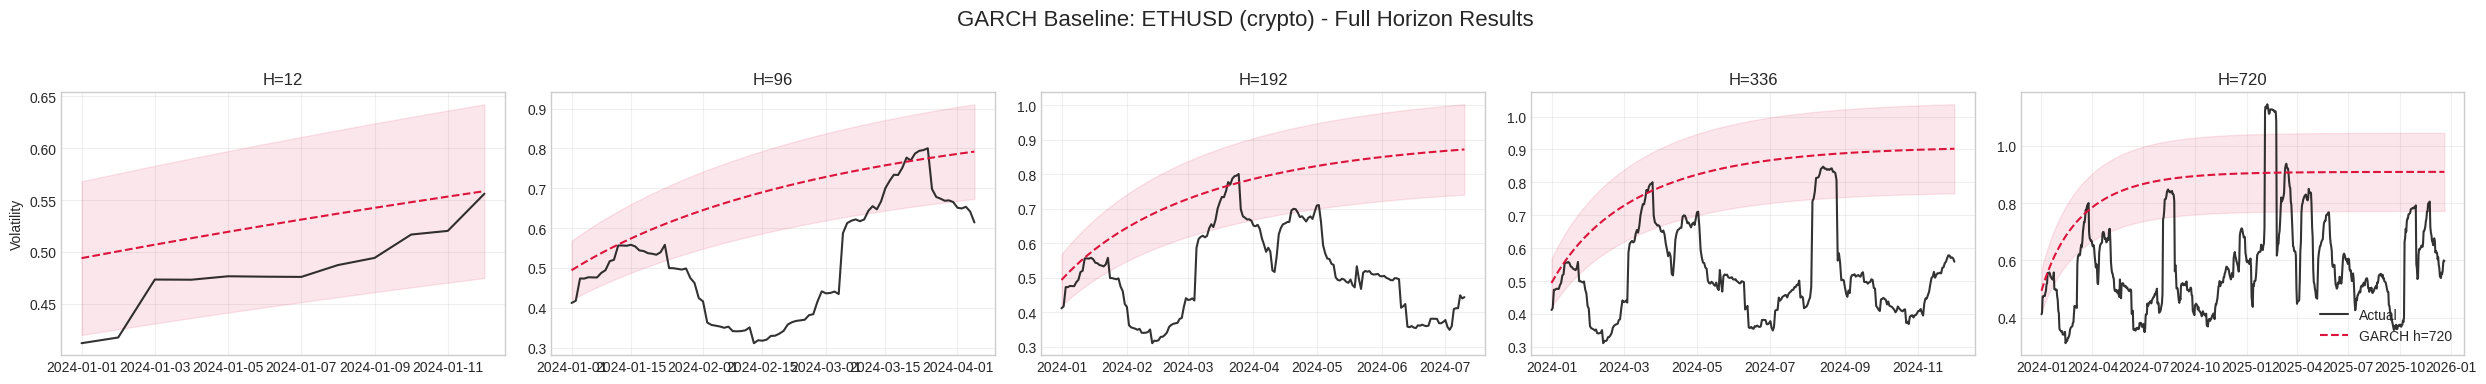

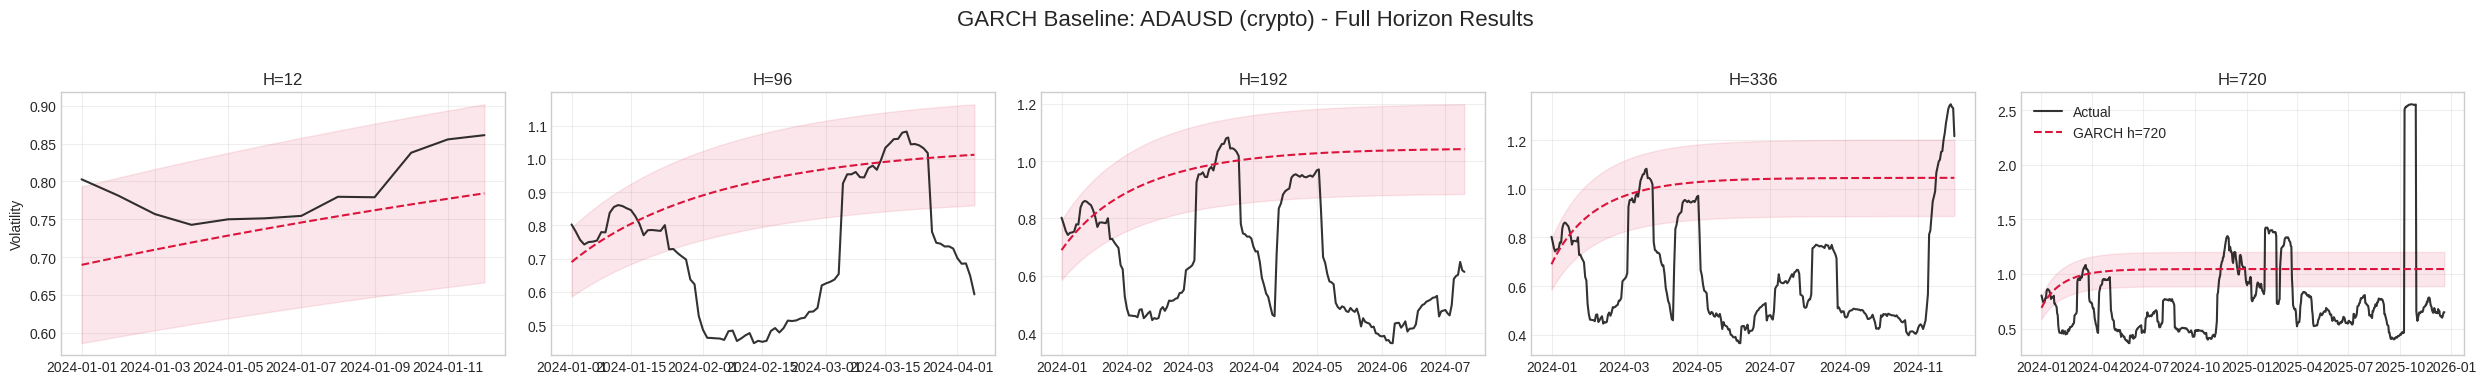

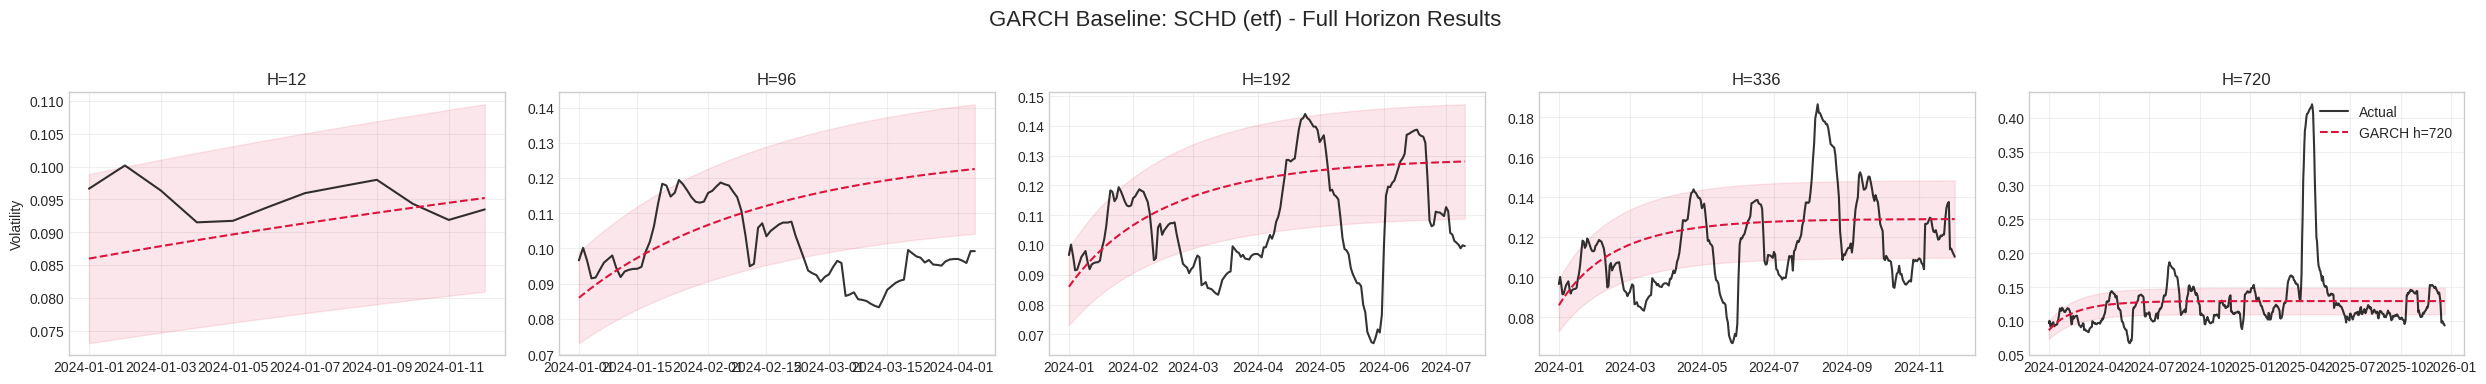

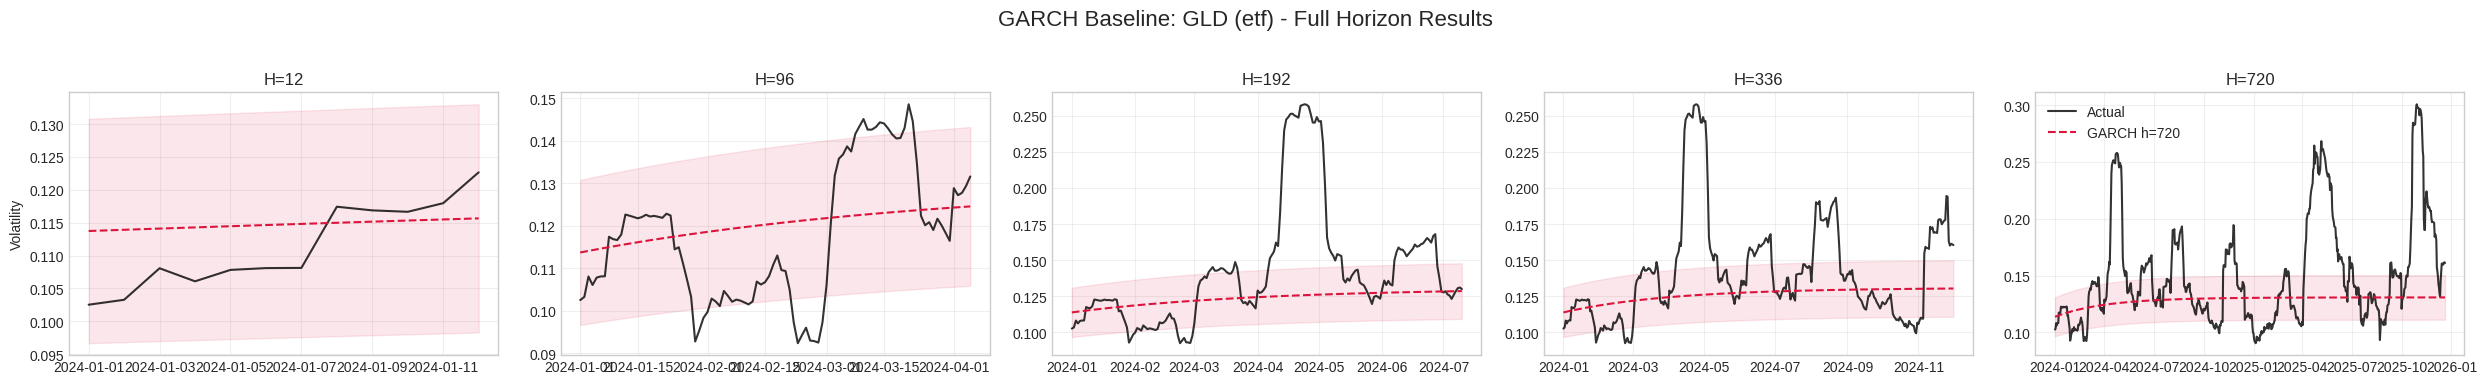

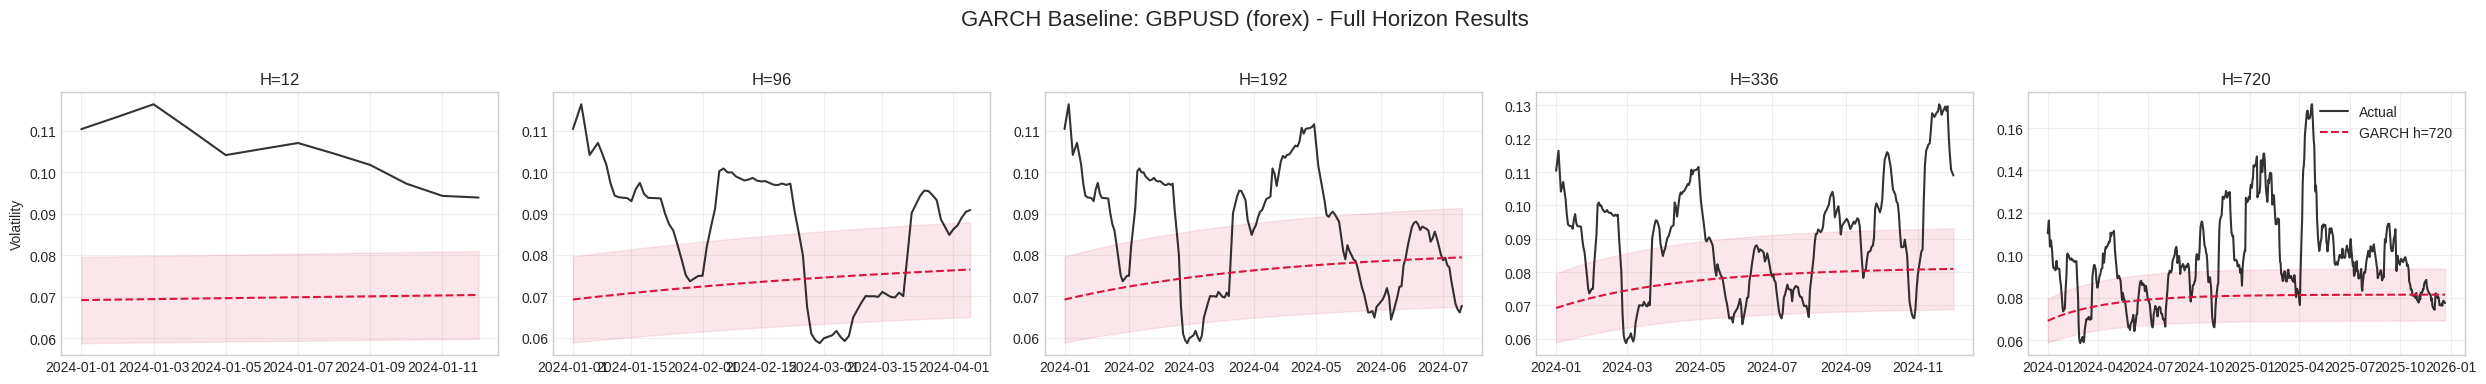

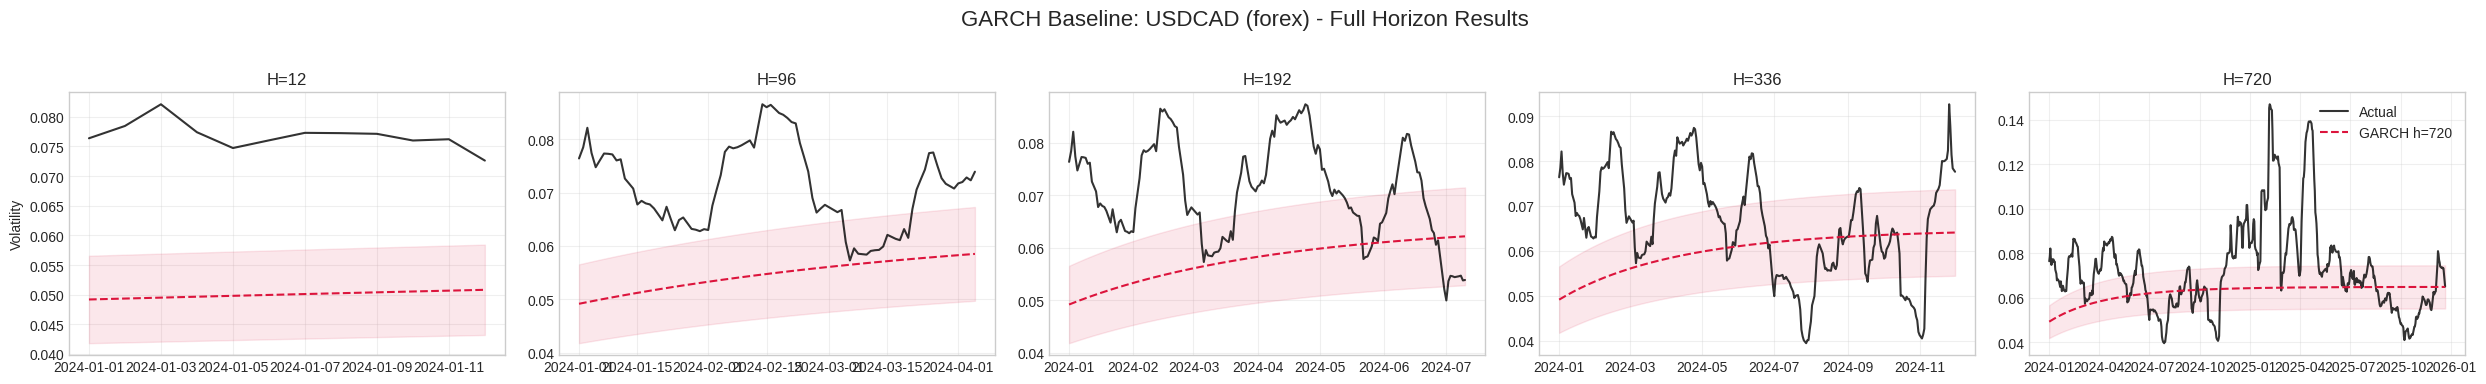

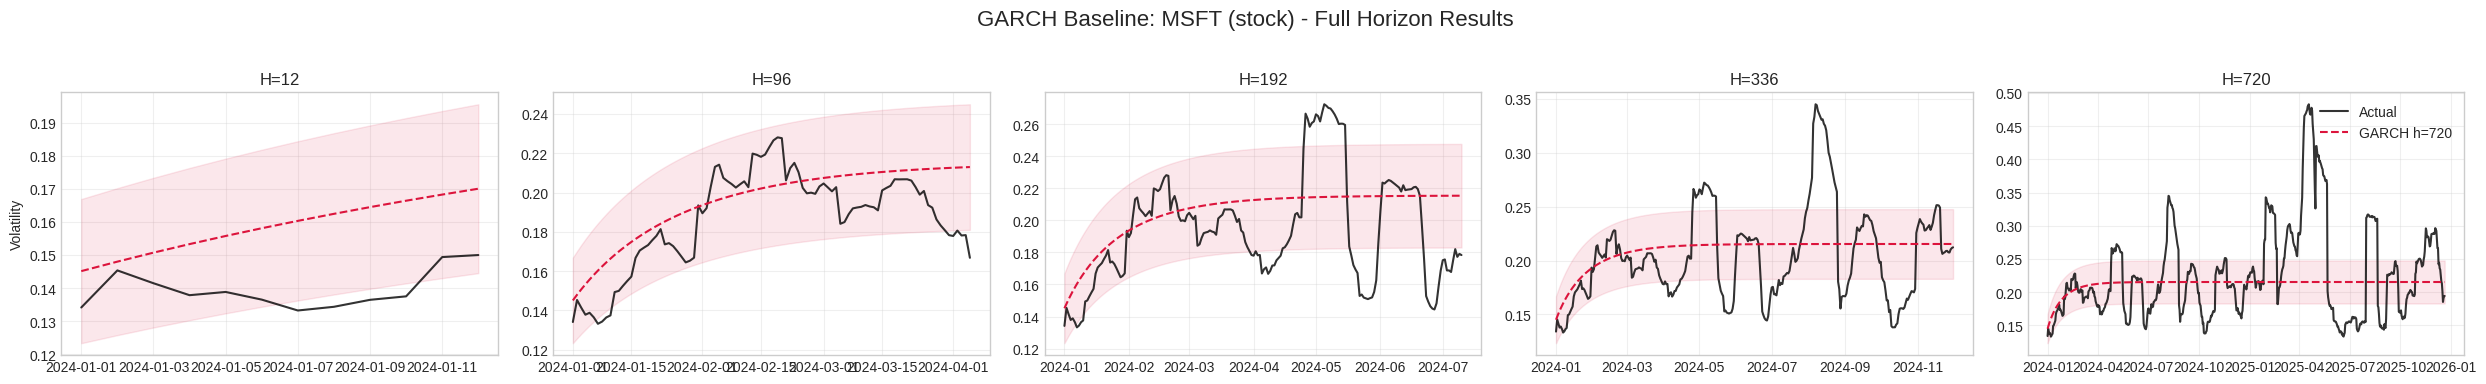

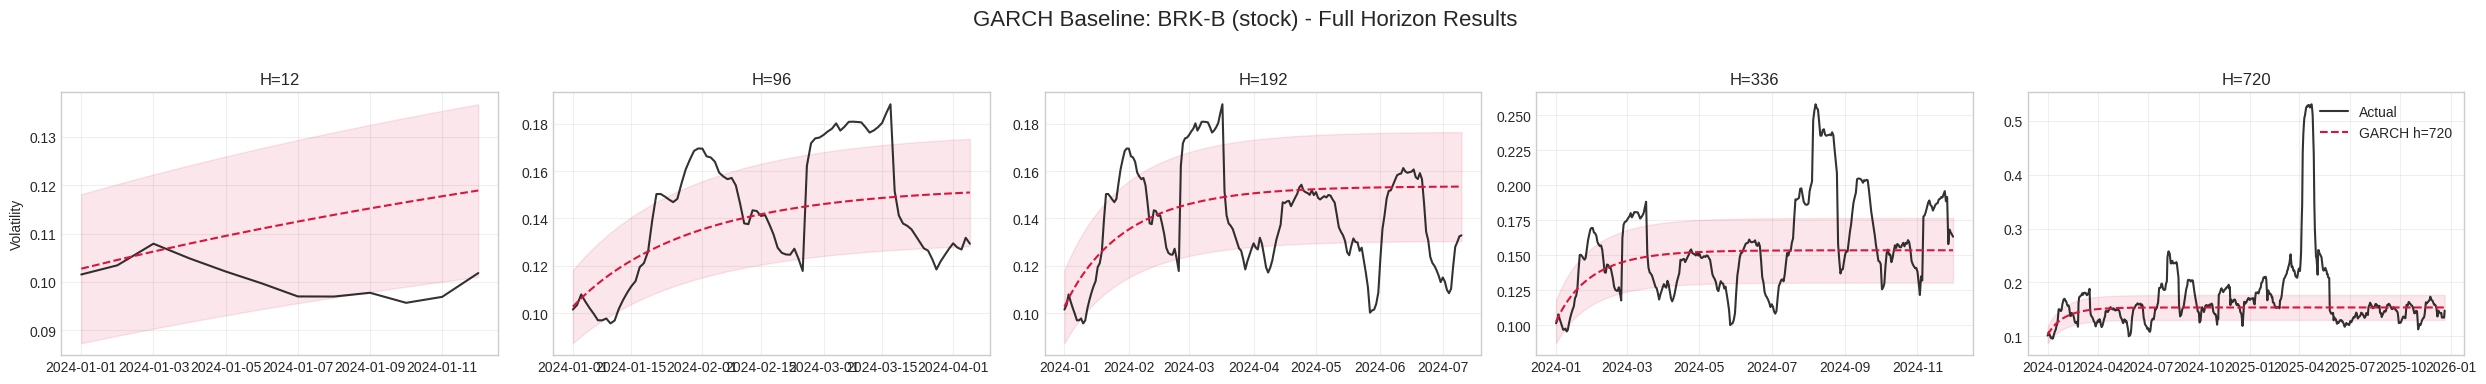

In [4]:
if not all_metrics:
    print("No results to plot.")
else:
    target_tickers = best_tickers['Ticker'].tolist()

    for ticker in target_tickers:
        asset_class = best_tickers[best_tickers['Ticker'] == ticker]['AssetClass'].values[0]
        fig, axes = plt.subplots(1, 5, figsize=(25, 4))
        fig.suptitle(f"GARCH Baseline: {ticker} ({asset_class}) - Full Horizon Results", fontsize=16)
        
        for idx, h in enumerate(horizons):
            if h not in all_results[ticker]:
                continue
            data = all_results[ticker][h]
            ax = axes[idx]
            
            ax.plot(data['dates'], data['actual'], label='Actual', color='black', alpha=0.8)
            ax.plot(data['dates'], data['pred'], label=f'GARCH h={h}', color='crimson', ls='--')
            ax.fill_between(data['dates'], data['pred']*0.85, data['pred']*1.15, color='crimson', alpha=0.1)
            
            ax.set_title(f"H={h}")
            ax.grid(True, alpha=0.3)
            if idx == 0: ax.set_ylabel("Volatility")
            if idx == 4: ax.legend()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

## Executive Summary
- **Exhaustive Baseline Complete**: We have benchmarked the entire set of tickers.
- **Definitive Baseline**: The results in `baseline_results_exhaustive.csv` will be the definitive comparison target for TimeMixer.